In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from IPython.display import display
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

#load the data:
data =  pd.read_csv(r"C:\Users\Monika Dogra\Desktop\data\salary_prediction_realistic_1000.csv")
display(data.head())

,Years_of_Experience,Education,City,Skills_Rating,Company_Size,Job_Role,Salary
0,8.1,Bachelors,Bangalore,2,Startup,Backend Developer,2349000
1,12.7,Bachelors,Pune,2,Mid,Data Analyst,3442000
2,13.8,Masters,Pune,10,Startup,Data Analyst,4039000
3,9.9,Bachelors,Bangalore,7,MNC,ML Engineer,3743000
4,3.6,Bachelors,Pune,2,Mid,Data Analyst,1009000


## Simple Regression model

In [11]:
#Basic information
display(data.shape)
display(data.info())
display(data.describe()) #df.describe() gives summary statistics for all numerical columns in the dataset.
#Standard deviation measures how much the data varies from the mean.
#25% of employees have 6 years or less of experience.in case of "Years_of_Experience"
#max :The most experienced employee has 25 years of experience.
#min:Someone has 0 years of experience.

(1000, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years_of_Experience  1000 non-null   float64
 1   Education            1000 non-null   object 
 2   City                 1000 non-null   object 
 3   Skills_Rating        1000 non-null   int64  
 4   Company_Size         1000 non-null   object 
 5   Job_Role             1000 non-null   object 
 6   Salary               1000 non-null   int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB


None

,Years_of_Experience,Skills_Rating,Salary
count,1000.000000,1000.000000,1.000000e+03
mean,12.568300,5.496000,4.028749e+06
std,7.125502,2.828424,2.076515e+06
min,0.000000,1.000000,2.500000e+05
25%,6.500000,3.000000,2.280250e+06
50%,12.350000,6.000000,3.946000e+06
75%,18.800000,8.000000,5.651750e+06
max,25.000000,10.000000,1.001600e+07


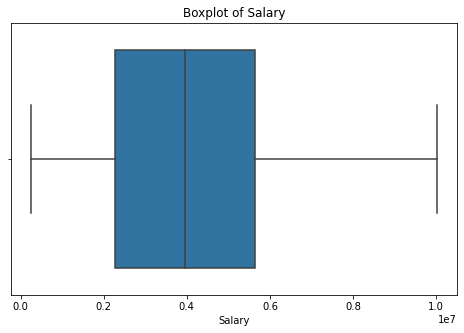

In [54]:
# outliers for salary col.
plt.figure(figsize=(8,5))
sns.boxplot(x=data["Salary"])
plt.title("Boxplot of Salary")
plt.show()

# max salary is coming within upper bound after all the calculation w.r.t IQR : Q3 + 1.5 × IQR so there is no outliers

df.describe() helps me identify possible outliers by comparing the minimum and maximum values with the quartiles. In this dataset, the maximum salary appears much higher than the 75th percentile, so it suggests there may be outliers. However, I cannot confirm this from describe() alone. I would calculate the IQR or visualize the data using a box plot. After applying the IQR rule here, the maximum salary falls within the acceptable upper bound, so there are no statistical outliers in the Salary column."

How to Use df.describe() During EDA

For your salary dataset, you can use it to answer questions like:

Are there missing values?
Compare count with the total number of rows.

What is the average experience?
Look at the mean for Years_of_Experience.

What is the average salary?
Look at the mean for Salary.

Is the salary spread wide or narrow?
Compare the std with the mean.

Are there possible outliers?
If the max is much larger than the 75% value, or the min is much smaller than the 25% value, it may indicate outliers. This can be confirmed using a box plot.

In [14]:
# checking for missing values:
data.isnull().sum()

Years_of_Experience    0
Education              0
City                   0
Skills_Rating          0
Company_Size           0
Job_Role               0
Salary                 0
dtype: int64

In [19]:
# check fro duplicates:
data.duplicated().sum()
# if required:
data = data.drop_duplicates()

In [20]:
display(data.shape)

(1000, 7)

,Years_of_Experience,Skills_Rating,Salary
0,8.1,2,2349000
1,12.7,2,3442000
2,13.8,10,4039000
3,9.9,7,3743000
4,3.6,2,1009000


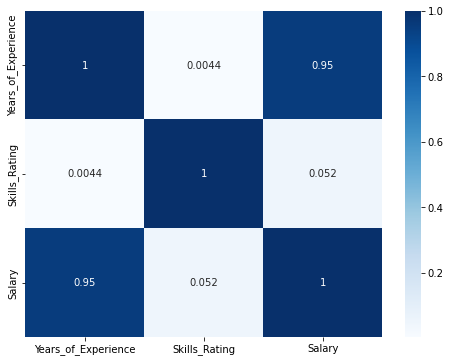

In [26]:
#Correlation:
# Since Simple Linear Regression only uses numerical columns

numeric_df = data.select_dtypes(include= np.number)
display(numeric_df.head())
print()
plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap="Blues")
plt.show()

# Years_of_Experience

# ↓

# Salary

# Strong Positive Correlation

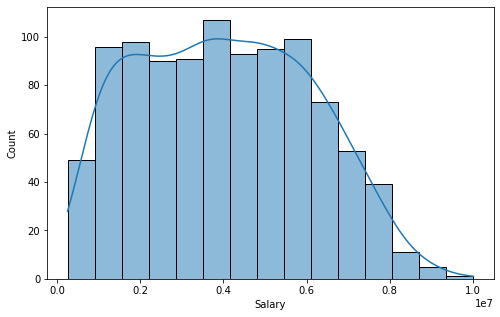

In [28]:
#Distribution of Salary
plt.figure(figsize=(8,5))

sns.histplot(data["Salary"],
             kde=True)

plt.show()

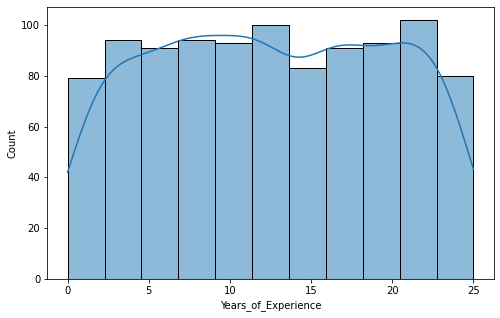

In [29]:
#Distribution of Experience
plt.figure(figsize=(8,5))

sns.histplot(data["Years_of_Experience"],
             kde=True)

plt.show()

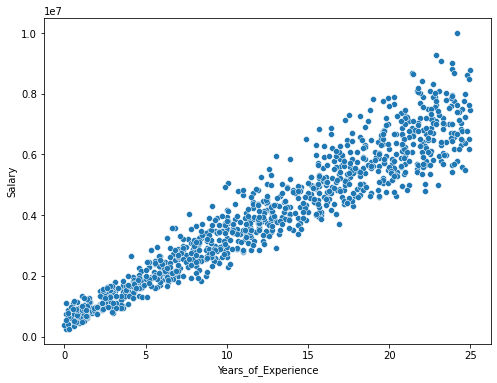

In [31]:
#scatter plot:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Years_of_Experience",
    y="Salary",
    data=data
)

plt.show()

In [34]:
# select features:
x = data[["Years_of_Experience"]]
y = data["Salary"]

In [61]:
display(x.head())

,Years_of_Experience
0,8.1
1,12.7
2,13.8
3,9.9
4,3.6


In [64]:
display(type(y))

pandas.core.series.Series

X

Double brackets

y

Single brackets

Why?

Because

X

must always be 2D

y

must be 1D

In [35]:
# train test split:
X_train, X_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)
# why random_state:To make the train-test split reproducible

In [36]:
#train the model:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [38]:
#model parameters:
# slope:
display(model.coef_)
display(model.intercept_)

# Salary = Intercept +Slope × Experienc

array([278318.13889895])

548560.154289891

In [44]:
# prediction:
y_pred = model.predict(X_test)
# display(pred)

In [45]:
#Compare Actual vs Predicted
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
521,992000,6.598874e+05
737,5516000,4.055369e+06
740,1111000,1.188692e+06
660,4158000,5.112978e+06
411,4804000,5.279969e+06
678,7507000,7.367355e+06
626,5801000,6.448905e+06
513,4634000,5.947932e+06
859,4280000,4.083201e+06
136,1363000,1.272187e+06


In [48]:
#evaluation:
mae = mean_absolute_error(y_test, y_pred)

print(mae)
#MAE is only about 12% of the average salary.
# That is reasonably accurate.

mse = mean_squared_error(y_test, y_pred)

print(mse)

rmse = np.sqrt(mse)

print(rmse)
#RMSE isn't dramatically larger than MAE.
# This means you don't have many extremely bad predictions

481552.8476398572
389604005364.73236
624182.6698689514


In [49]:
r2 = r2_score(y_test, y_pred)

print(r2)
#The model explains about 90.12% of the variation in salary.
#0.901

# falls into the Very Good range.

0.9012051985847391


R²	Interpretation

<0.50	Poor

0.50–0.70	Acceptable

0.70–0.85	Good

0.85–0.95	Very Good

>0.95	Excellent (but sometimes may indicate overfitting)

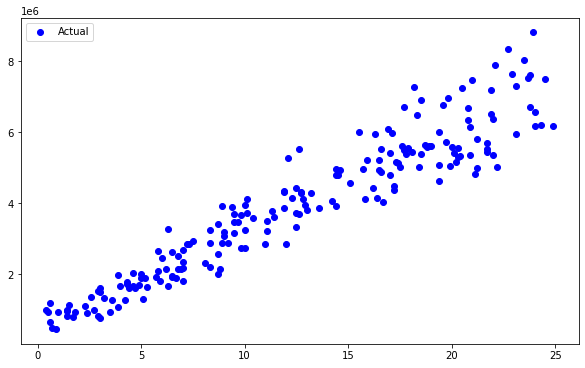

In [53]:
#Plot Regression Line
plt.figure(figsize=(10,6))

plt.scatter(X_test,
            y_test,
            color="blue",
            label="Actual")

# plt.plot(X_test,
#          y_pred,
#          color="red",
#          linewidth=3,
#          label="Regression Line")

# plt.xlabel("Years of Experience")
# plt.ylabel("Salary")

plt.legend()

plt.show()

In [51]:
experience = [[5]]

prediction = model.predict(experience)

print(prediction)

[1940150.84878466]


C:\Users\Monika Dogra\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [52]:
new_data = pd.DataFrame({
    "Years_of_Experience": [5]
})

prediction = model.predict(new_data)

print(prediction)

[1940150.84878466]


## Multiple Linear Regression

Salary = β₀ + β₁ × Experience

Salary = β₀
       + β₁ × Experience
       + β₂ × Skills_Rating
       + β₃ × Education
       + β₄ × City
       + β₅ × Company_Size
       + β₆ × Job_Role

Here:

β₀ = Intercept
β₁...β₆ = Coefficients learned by the model

Complete Workflow

Here's the workflow you'll follow:

Load Dataset
       │
       ▼
Basic EDA
       │
       ▼
Check Missing Values
       │
       ▼
Check Duplicates
       │
       ▼
Separate Numerical & Categorical Features
       │
       ▼
Encode Categorical Variables
       │
       ▼
Train-Test Split
       │
       ▼
Train Multiple Linear Regression
       │
       ▼
Prediction
       │
       ▼
Evaluation
       │
       ▼
Interpret Coefficients

In [56]:
df = pd.read_csv(r"C:\Users\Monika Dogra\Desktop\data\salary_prediction_realistic_1000.csv")
display(df.head())

,Years_of_Experience,Education,City,Skills_Rating,Company_Size,Job_Role,Salary
0,8.1,Bachelors,Bangalore,2,Startup,Backend Developer,2349000
1,12.7,Bachelors,Pune,2,Mid,Data Analyst,3442000
2,13.8,Masters,Pune,10,Startup,Data Analyst,4039000
3,9.9,Bachelors,Bangalore,7,MNC,ML Engineer,3743000
4,3.6,Bachelors,Pune,2,Mid,Data Analyst,1009000


In [58]:
display(df.head())

display(df.info())

display(df.describe())

display(df.isnull().sum())

display(df.duplicated().sum())

,Years_of_Experience,Education,City,Skills_Rating,Company_Size,Job_Role,Salary
0,8.1,Bachelors,Bangalore,2,Startup,Backend Developer,2349000
1,12.7,Bachelors,Pune,2,Mid,Data Analyst,3442000
2,13.8,Masters,Pune,10,Startup,Data Analyst,4039000
3,9.9,Bachelors,Bangalore,7,MNC,ML Engineer,3743000
4,3.6,Bachelors,Pune,2,Mid,Data Analyst,1009000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years_of_Experience  1000 non-null   float64
 1   Education            1000 non-null   object 
 2   City                 1000 non-null   object 
 3   Skills_Rating        1000 non-null   int64  
 4   Company_Size         1000 non-null   object 
 5   Job_Role             1000 non-null   object 
 6   Salary               1000 non-null   int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 54.8+ KB


None

,Years_of_Experience,Skills_Rating,Salary
count,1000.000000,1000.000000,1.000000e+03
mean,12.568300,5.496000,4.028749e+06
std,7.125502,2.828424,2.076515e+06
min,0.000000,1.000000,2.500000e+05
25%,6.500000,3.000000,2.280250e+06
50%,12.350000,6.000000,3.946000e+06
75%,18.800000,8.000000,5.651750e+06
max,25.000000,10.000000,1.001600e+07


Years_of_Experience    0
Education              0
City                   0
Skills_Rating          0
Company_Size           0
Job_Role               0
Salary                 0
dtype: int64

0

In [60]:
X = df.drop("Salary", axis=1)
display(X)

,Years_of_Experience,Education,City,Skills_Rating,Company_Size,Job_Role
0,8.1,Bachelors,Bangalore,2,Startup,Backend Developer
1,12.7,Bachelors,Pune,2,Mid,Data Analyst
2,13.8,Masters,Pune,10,Startup,Data Analyst
3,9.9,Bachelors,Bangalore,7,MNC,ML Engineer
4,3.6,Bachelors,Pune,2,Mid,Data Analyst
...,...,...,...,...,...,...
995,18.3,PhD,Pune,1,Mid,Data Analyst
996,20.3,Bachelors,Pune,4,MNC,Data Analyst
997,22.5,Bachelors,Delhi,3,Startup,Software Engineer
998,16.7,Bachelors,Chennai,5,Startup,Backend Developer


In [66]:
# Which columns are categorical?
X.dtypes

Years_of_Experience    float64
Education               object
City                    object
Skills_Rating            int64
Company_Size            object
Job_Role                object
dtype: object

In [68]:
X.nunique()

Years_of_Experience    243
Education                3
City                     6
Skills_Rating           10
Company_Size             3
Job_Role                 5
dtype: int64

In [72]:
X = pd.get_dummies(
    X,
    drop_first=True
)
display(X.head())

#Bachelors becomes the reference category because of drop_first=True

,Years_of_Experience,Skills_Rating,Education_Masters,Education_PhD,City_Chennai,City_Delhi,City_Hyderabad,City_Mumbai,City_Pune,Company_Size_Mid,Company_Size_Startup,Job_Role_Data Analyst,Job_Role_Data Scientist,Job_Role_ML Engineer,Job_Role_Software Engineer
0,8.1,2,0,0,0,0,0,0,0,0,1,0,0,0,0
1,12.7,2,0,0,0,0,0,0,1,1,0,1,0,0,0
2,13.8,10,1,0,0,0,0,0,1,0,1,1,0,0,0
3,9.9,7,0,0,0,0,0,0,0,0,0,0,0,1,0
4,3.6,2,0,0,0,0,0,0,1,1,0,1,0,0,0


Why did you use drop_first=True?

To avoid the Dummy Variable Trap (perfect multicollinearity), where one dummy variable can be exactly predicted from the others. Dropping one category makes it the reference category while preserving all the information needed for the model.

In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
display(X_train.head())
display(X_test.head())
display(y_train.head())
display(y_test.head())
display(y_test.shape)

,Years_of_Experience,Skills_Rating,Education_Masters,Education_PhD,City_Chennai,City_Delhi,City_Hyderabad,City_Mumbai,City_Pune,Company_Size_Mid,Company_Size_Startup,Job_Role_Data Analyst,Job_Role_Data Scientist,Job_Role_ML Engineer,Job_Role_Software Engineer
29,0.7,10,1,0,0,0,0,0,1,1,0,1,0,0,0
535,2.7,4,1,0,0,0,0,1,0,0,1,0,0,0,0
695,2.3,4,0,0,1,0,0,0,0,1,0,0,0,0,1
557,18.4,7,0,0,1,0,0,0,0,1,0,0,0,0,0
836,13.3,6,0,0,0,0,1,0,0,1,0,0,1,0,0


,Years_of_Experience,Skills_Rating,Education_Masters,Education_PhD,City_Chennai,City_Delhi,City_Hyderabad,City_Mumbai,City_Pune,Company_Size_Mid,Company_Size_Startup,Job_Role_Data Analyst,Job_Role_Data Scientist,Job_Role_ML Engineer,Job_Role_Software Engineer
521,0.4,8,1,0,0,1,0,0,0,0,0,1,0,0,0
737,12.6,9,1,0,0,0,0,1,0,0,0,1,0,0,0
740,2.3,4,1,0,0,0,0,0,1,0,0,1,0,0,0
660,16.4,8,0,0,1,0,0,0,0,0,1,0,0,0,0
411,17.0,2,0,0,0,1,0,0,0,1,0,0,0,0,0


29      833000
535    1406000
695     901000
557    5024000
836    3802000
Name: Salary, dtype: int64

521     992000
737    5516000
740    1111000
660    4158000
411    4804000
Name: Salary, dtype: int64

(200,)

In [83]:
model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [86]:
y_pred = model.predict(X_test)
display(y_pred.shape)

(200,)

In [87]:
mae = mean_absolute_error(y_test, y_pred)

mse = mean_squared_error(y_test, y_pred)

rmse = np.sqrt(mse)

r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R2 :", r2)

MAE : 228642.52889033456
MSE : 90940461217.87961
RMSE: 301563.36186261027
R2 : 0.9769395471224128


# Compare with Simple Linear Regression

Metric	Simple LR	Multiple LR
MAE	    ₹4.81 lakh	Lower (expected)
RMSE	₹6.24 lakh	Lower (expected)
R²	      0.90	    Higher (expected)

Since the dataset was generated using all six features, Multiple Linear Regression should perform better because it uses all the information available.

In [91]:
# Feature Importance (Coefficients)

# One of the best parts of Multiple Linear Regression is that you can inspect the coefficients.

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

display(coefficients)

,Feature,Coefficient
3,Education_PhD,1.052346e+06
2,Education_Masters,4.569907e+05
0,Years_of_Experience,2.761367e+05
7,City_Mumbai,1.952936e+05
1,Skills_Rating,3.140354e+04
12,Job_Role_Data Scientist,-1.272150e+03
11,Job_Role_Data Analyst,-4.858598e+03
14,Job_Role_Software Engineer,-2.300984e+04
13,Job_Role_ML Engineer,-2.413648e+04
5,City_Delhi,-2.026902e+05


Why didn't you scale the features?

Scaling is not required for ordinary least squares Linear Regression. The algorithm can learn correctly with features on different scales. However, scaling can make coefficient comparisons easier and is important for algorithms like KNN, SVM, or regularized regression (Ridge/Lasso).

Visual Representation
Training Data

        │
        ▼

fit()

Learns

Mean

Std

Categories

Median

etc.

        │
        ▼

transform()

Uses learned information

        │
        ▼

Transformed Data

fit() learns the parameters from the data, while transform() applies those learned parameters to convert the data.

Does fit() change the dataset?

Answer:

No. fit() only learns information from the data. It does not modify the dataset.

When should we use fit_transform()?

Answer:

fit_transform() is typically used on the training data because it first learns the preprocessing parameters and then applies the transformation in a single step.

Why don't we use fit_transform() on the test data?

Answer:

Using fit_transform() on the test data would cause the preprocessing object to learn information from the test set. This leads to data leakage and gives an unrealistic evaluation of the model. The correct approach is to fit on the training data and only transform the test data.

A Simple Way to Remember

Imagine you're learning to make tea:

fit() → Read and understand the recipe.
transform() → Make tea using the recipe you've already learned.
fit_transform() → Read the recipe and make the tea in one go.